<a href="https://colab.research.google.com/github/Harjot-Kaur25/EDA-/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving WineQT.csv to WineQT.csv


In [39]:
import pandas as pd

df = pd.read_csv('WineQT.csv')
display(df.head(5))

print(df.tail())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1138            6.3             0.510         0.13             2.3      0.076   
1139            6.8             0.620         0.08             1.9      0.068   
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645         0.12             2.0      0.075   

      free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
1138                 29.0                  40.0  0.99574  3.42       0.75   
1139                 28.0                  38.0  0.99651  3.42       0.82   
1140                 32.0                  44.0  0.99490  3.45       0.58   
1141                 39.0                  51.0  0.99512  3.52       0.76   
1142                 32.0                  44.0  0.99547  3.57       0.71   

      alcohol  quality    Id  
1138     11.0      

In [33]:
print(df.dtypes)
print("***************************************************************************************************************")
print(df.describe())
print("***************************************************************************************************************")

print('Checking for missing values:')
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object
***************************************************************************************************************
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.

,0


No missing values found in the dataset.


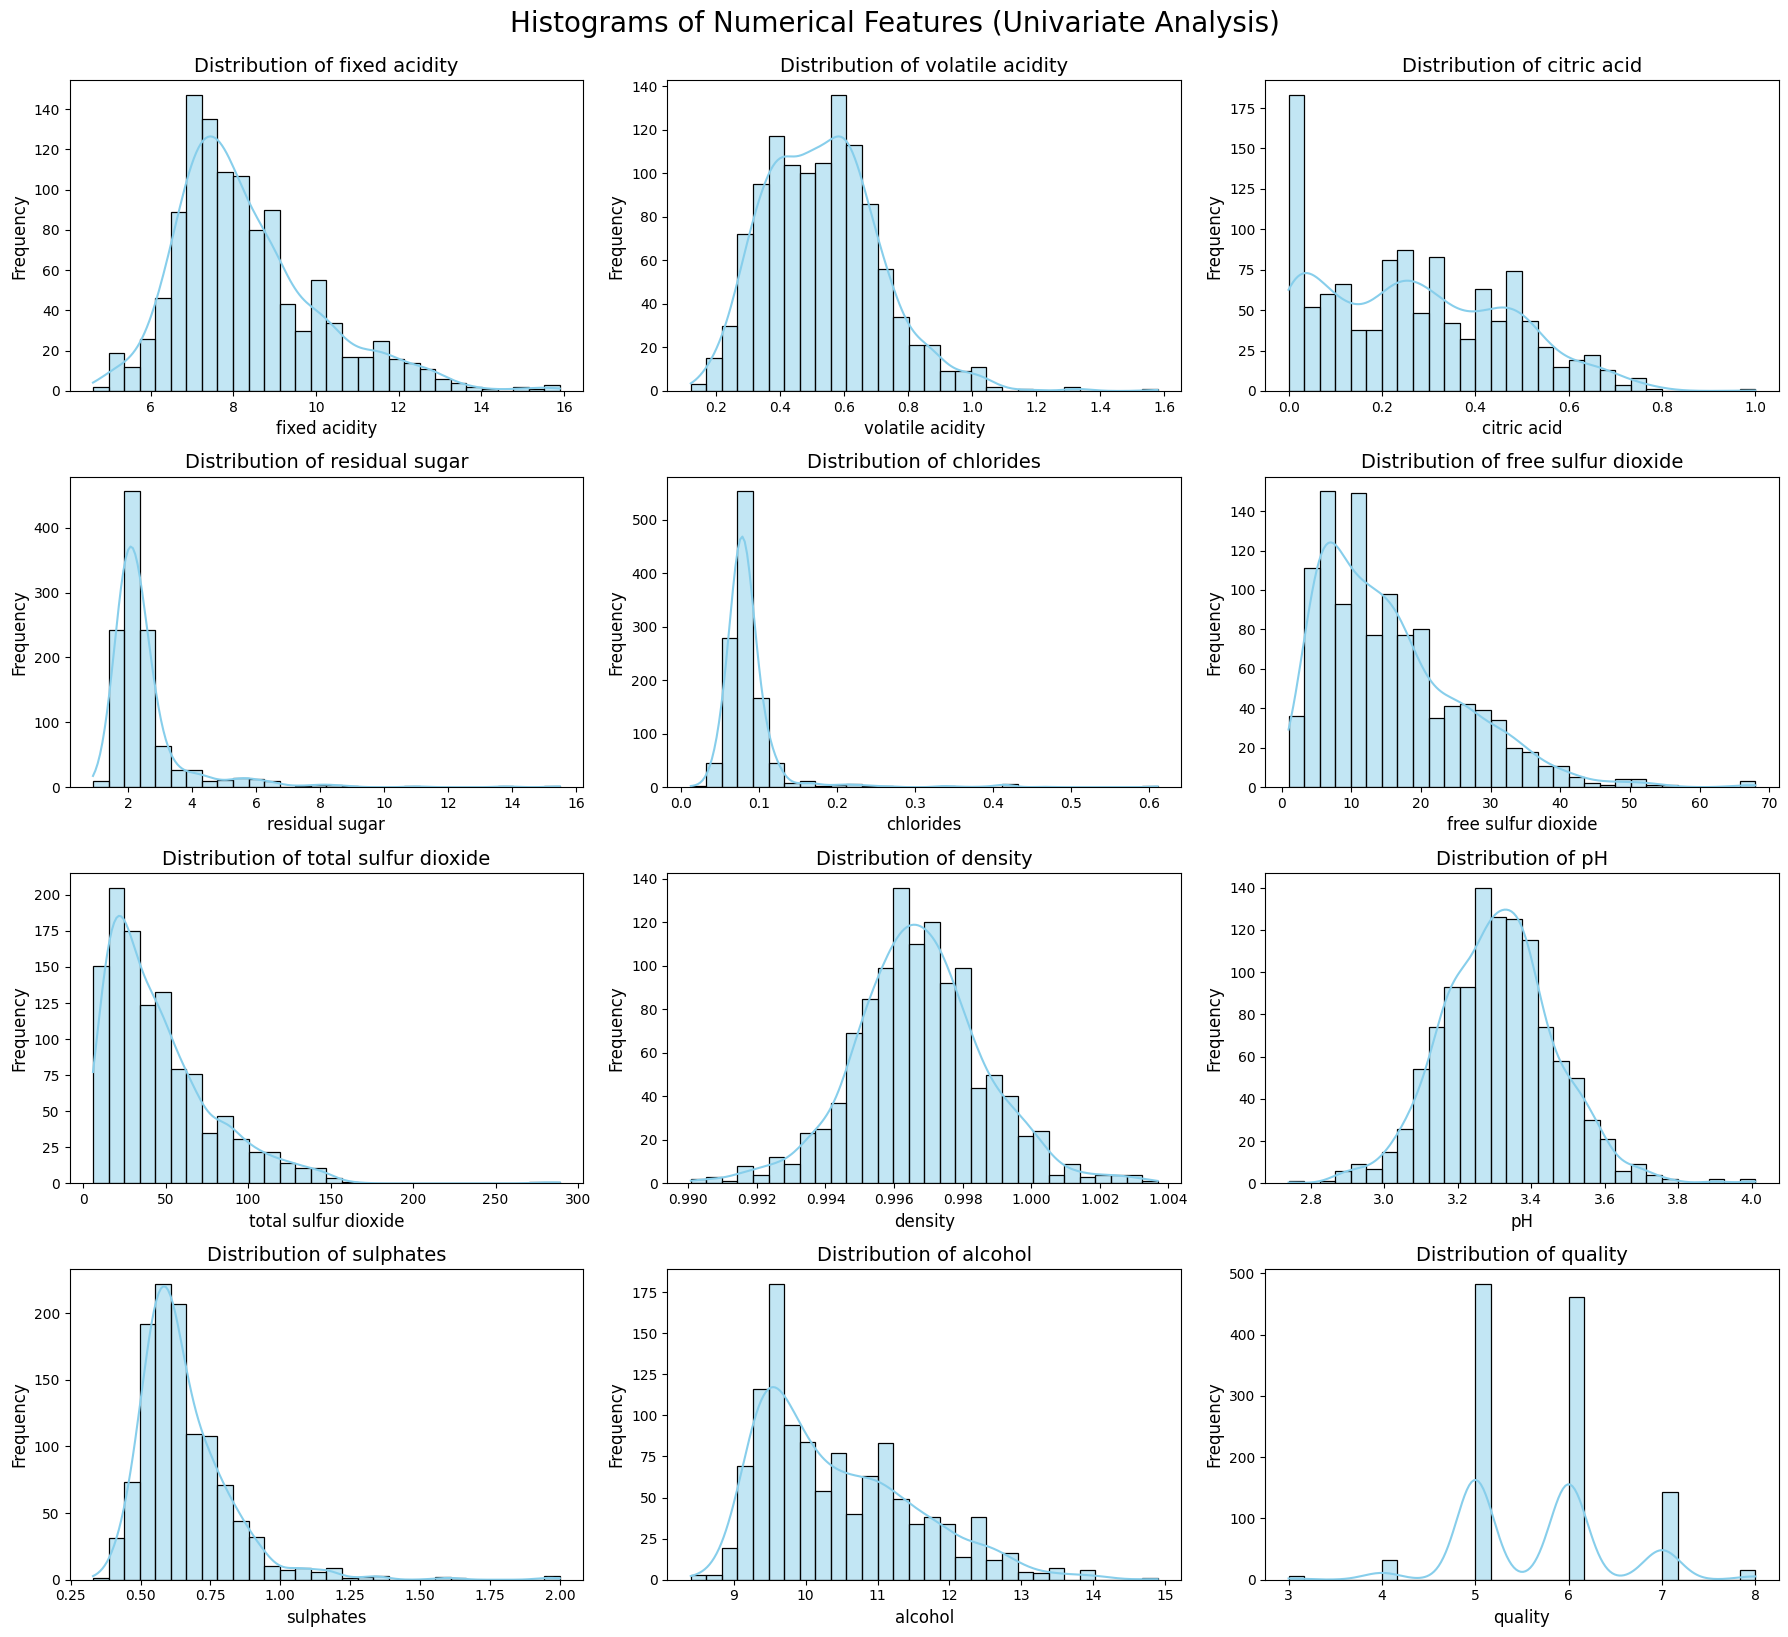

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'Id' in numerical_cols:
    numerical_cols.remove('Id')
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30, color='skyblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.suptitle('Histograms of Numerical Features (Univariate Analysis)', y=1.02, fontsize=20)
plt.show()

In [17]:
print("Compute the measure of central tendency for the 'alcohol' column:")
mean_alcohol = df["alcohol"].mean()
median_alcohol = df["alcohol"].median()
mode_alcohol = df["alcohol"].mode()

print(f"Mean of alcohol: {mean_alcohol:.2f}")
print(f"Median of alcohol: {median_alcohol:.2f}")
print(f"Mode of alcohol: {mode_alcohol.to_list()}")

Compute the measure of central tendency for the 'alcohol' column:
Mean of alcohol: 10.44
Median of alcohol: 10.20
Mode of alcohol: [9.5]


Bar chart for the 'quality' column:


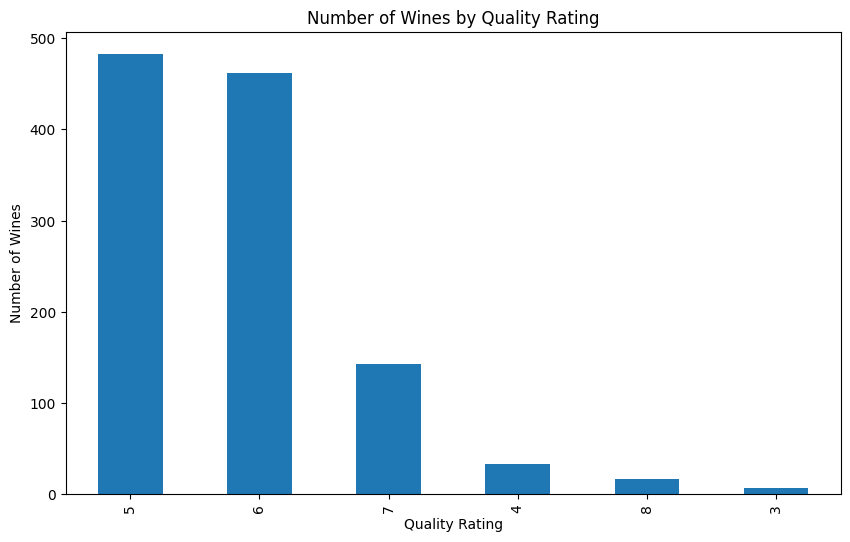

In [18]:
import matplotlib.pyplot as plt

print("Bar chart for the 'quality' column:")
df['quality'].value_counts().nlargest(30).plot(kind='bar', figsize=(10,6))
plt.title("Number of Wines by Quality Rating")
plt.ylabel('Number of Wines')
plt.xlabel('Quality Rating')
plt.show()

Bivariate Analysis


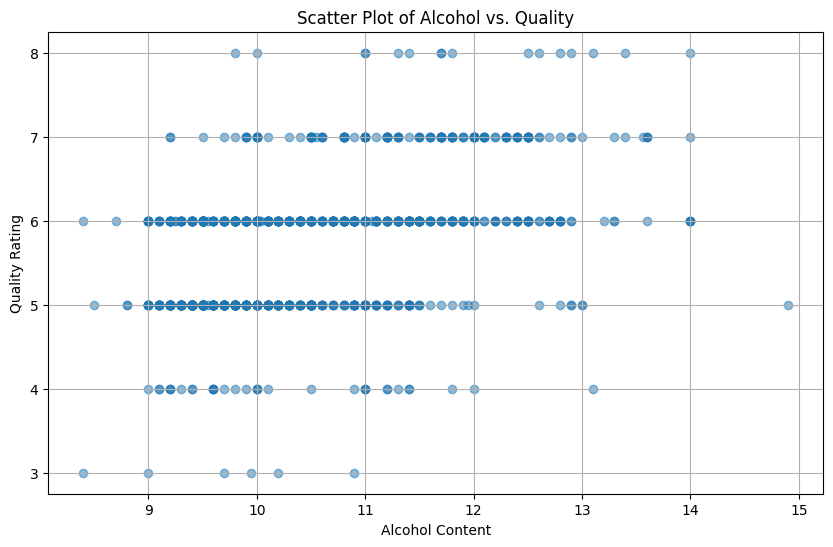

In [38]:
import matplotlib.pyplot as plt
print("Bivariate Analysis")
plt.figure(figsize=(10, 6))
plt.scatter(df['alcohol'], df['quality'], alpha=0.5)
plt.title('Scatter Plot of Alcohol vs. Quality')
plt.xlabel('Alcohol Content')
plt.ylabel('Quality Rating')
plt.grid(True)
plt.show()

In [19]:
print("Correlation matrix for the current dataset (using Pearson method):")
correlation = df.corr(method='pearson', numeric_only=True)
display(correlation)

Correlation matrix for the current dataset (using Pearson method):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970,-0.275826
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394,-0.007892
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821,-0.139011
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002,-0.046344
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085,-0.088099
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260,0.095268
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339,-0.107389
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208,-0.363926
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453,0.132904
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710,-0.103954


In [27]:

quality_correlations = correlation['quality'].sort_values(ascending=False)
display(quality_correlations)

,quality
quality,1.000000
alcohol,0.484866
sulphates,0.257710
citric acid,0.240821
fixed acidity,0.121970
Id,0.069708
residual sugar,0.022002
pH,-0.052453
free sulfur dioxide,-0.063260
chlorides,-0.124085


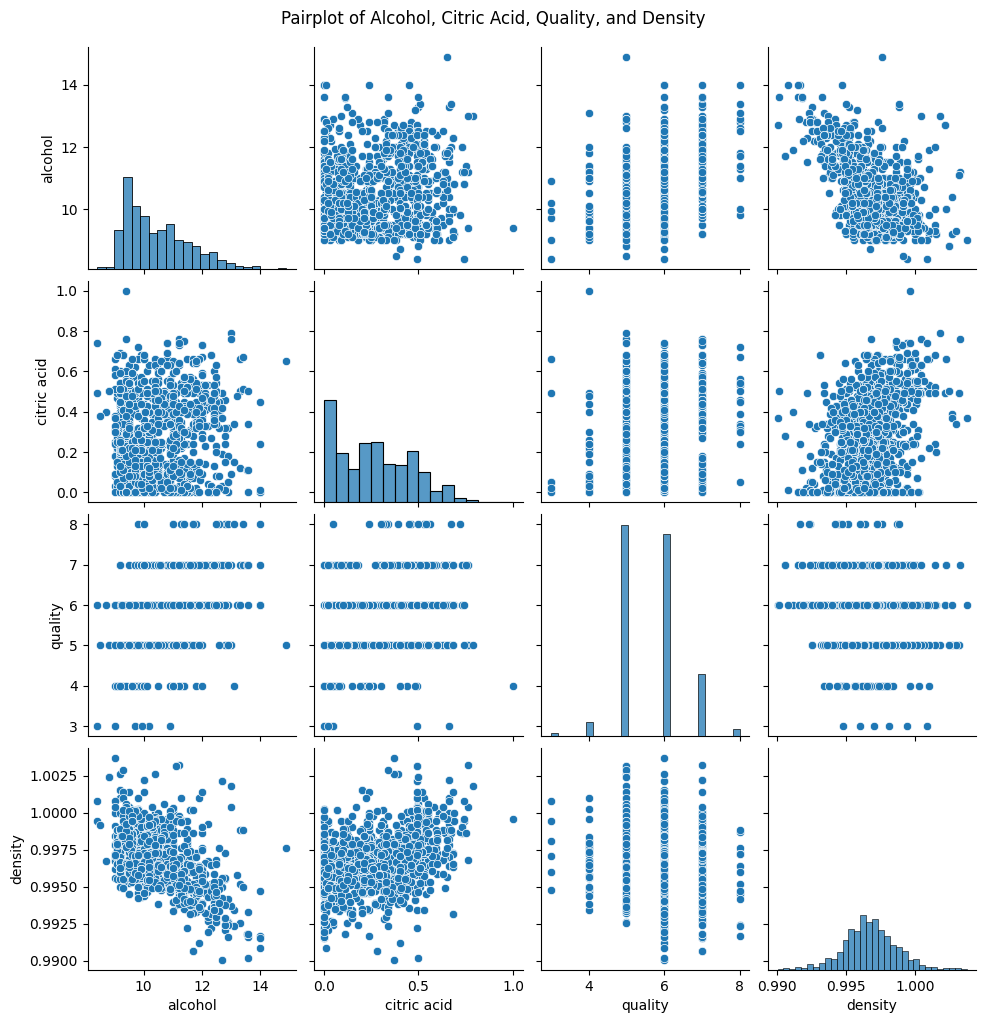

In [30]:
columns_for_new_pairplot = ['alcohol', 'citric acid', 'quality', 'density']

sns.pairplot(df[columns_for_new_pairplot])
plt.suptitle('Pairplot of Alcohol, Citric Acid, Quality, and Density', y=1.02)
plt.show()

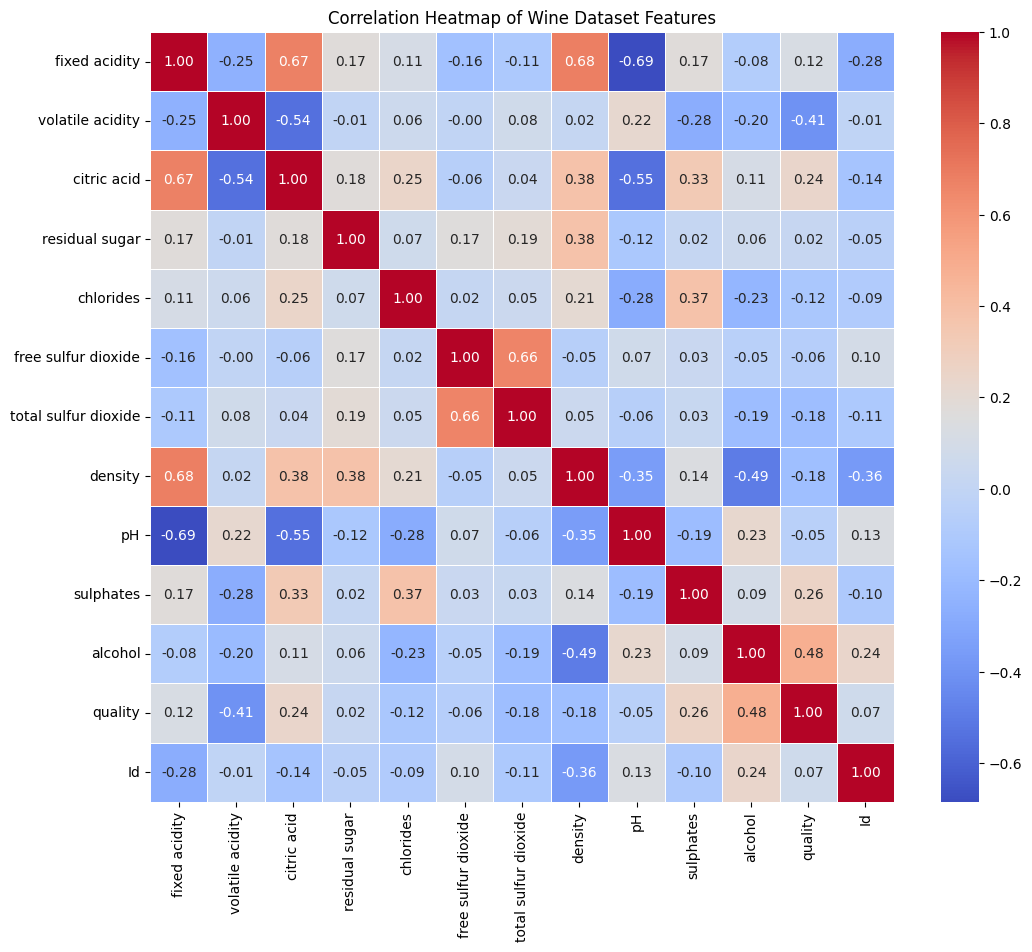

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Wine Dataset Features')
plt.show()

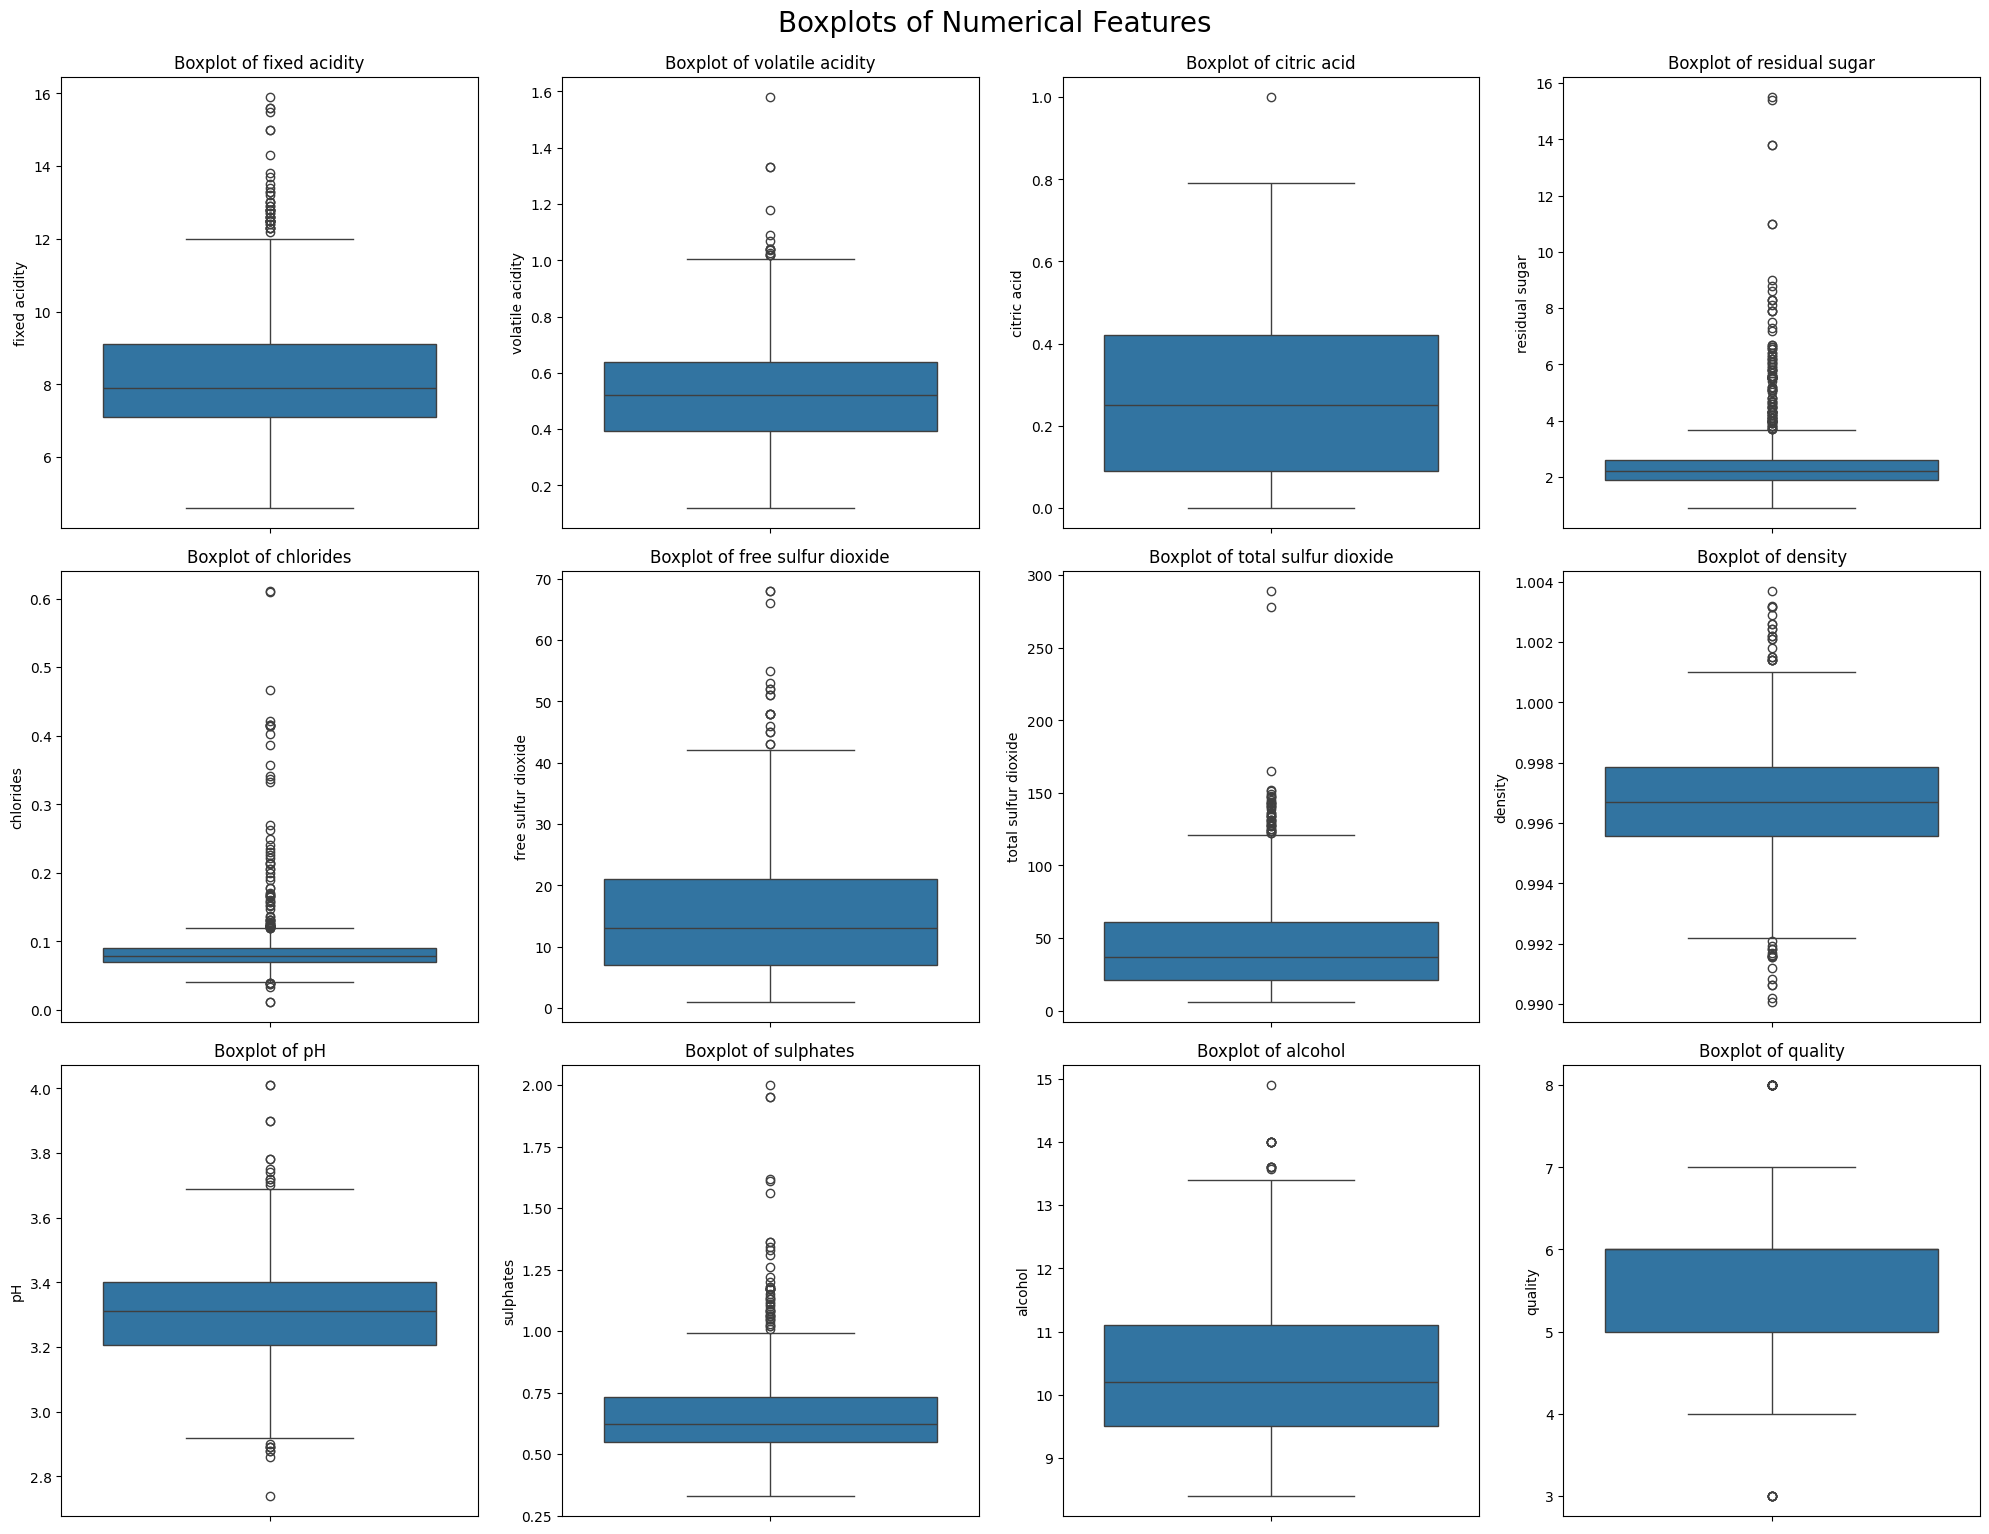

In [25]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
axes = axes.flatten()

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Exclude 'Id' as it's just an identifier
if 'Id' in numerical_cols:
    numerical_cols.remove('Id')

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(f'Boxplot of {col}')
        axes[i].set_ylabel(col)

plt.tight_layout()
plt.suptitle('Boxplots of Numerical Features', y=1.02, fontsize=20)
plt.show()